In [ ]:
!pip install -q -U bitsandbytes>=0.46.1
!pip install -q transformers accelerate datasets scipy matplotlib sentencepiece protobuf
print("✅ Done!")

✅ Done!


# Load Model

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
import time, re, warnings
warnings.filterwarnings('ignore')

MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

print(f"Loading {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    device_map="auto" if torch.cuda.is_available() else "cpu",
    trust_remote_code=True,
)
model.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Model loaded on {device}")
if torch.cuda.is_available():
    used  = torch.cuda.memory_allocated()/1e9
    total = torch.cuda.get_device_properties(0).total_memory/1e9
    print(f"💾 VRAM: {used:.1f}GB / {total:.1f}GB")

Loading TinyLlama/TinyLlama-1.1B-Chat-v1.0...


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

✅ Model loaded on cuda
💾 VRAM: 2.2GB / 15.6GB


# 5 Prompting Strategies

In [ ]:
def make_baseline(query):
    return query

def make_prompt_repetition(query):
    return f"{query}\n{query}"

def make_prompt_repetition_verbose(query):
    return f"{query}\nLet me repeat that:\n{query}"

def make_prompt_repetition_x3(query):
    return f"{query}\nLet me repeat that:\n{query}\nLet me repeat that one more time:\n{query}"

def make_padding(query):
    padding = "." * len(query)
    return f"{query}\nIgnore these periods (they are irrelevant) and answer the above question: {padding}"

STRATEGIES = {
    "Baseline":          make_baseline,
    "Repetition":        make_prompt_repetition,
    "Verbose":           make_prompt_repetition_verbose,
    "Repetition x3":     make_prompt_repetition_x3,
    "Padding(Control)":  make_padding,
}

print("✅ Strategies ready!")
for name, fn in STRATEGIES.items():
    sample = fn("What is 2+2?\nA.3 B.4 C.5 D.6")
    print(f"\n[{name}] ({len(sample)} chars)")
    print(sample[:120])

✅ Strategies ready!

[Baseline] (28 chars)
What is 2+2?
A.3 B.4 C.5 D.6

[Repetition] (57 chars)
What is 2+2?
A.3 B.4 C.5 D.6
What is 2+2?
A.3 B.4 C.5 D.6

[Verbose] (77 chars)
What is 2+2?
A.3 B.4 C.5 D.6
Let me repeat that:
What is 2+2?
A.3 B.4 C.5 D.6

[Repetition x3] (140 chars)
What is 2+2?
A.3 B.4 C.5 D.6
Let me repeat that:
What is 2+2?
A.3 B.4 C.5 D.6
Let me repeat that one more time:
What is 

[Padding(Control)] (131 chars)
What is 2+2?
A.3 B.4 C.5 D.6
Ignore these periods (they are irrelevant) and answer the above question: .................


# Inference Engine

In [ ]:
MAX_NEW_TOKENS = 20

def run_inference(prompt):
    inputs = tokenizer(
        prompt, return_tensors="pt",
        truncation=True, max_length=2048
    ).to(device)

    input_len = inputs["input_ids"].shape[1]
    start = time.time()

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )
    latency = time.time() - start

    new_tokens = output[0][input_len:]
    text = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
    return text, len(new_tokens), latency

def extract_letter(text):
    text = text.strip().upper()
    m = re.search(r'THE ANSWER IS\s*([A-D])', text)
    if m: return m.group(1)
    m = re.match(r'^([A-D])[.\)\s]', text)
    if m: return m.group(1)
    m = re.search(r'\b([A-D])\b', text)
    if m: return m.group(1)
    return "?"

# Quick test
out, ntok, lat = run_inference("The sky is: A. Red B. Blue C. Green. The answer is")
print(f"Output: '{out}' | Extracted: '{extract_letter(out)}' | Tokens: {ntok} | Latency: {lat:.2f}s")
print("✅ Inference ready!")

Output: ': B.

10. What is the temperature in the room? A. 2' | Extracted: 'B' | Tokens: 20 | Latency: 3.74s
✅ Inference ready!


# Load Datasets

In [ ]:
from datasets import load_dataset
import random
random.seed(42)

N_SAMPLES = 50   # Increase to 200 for more reliable results (takes longer)

# --- ARC ---
print("Loading ARC...")
arc_raw = load_dataset("ai2_arc", "ARC-Challenge", split="test")
arc_idx = random.sample(range(len(arc_raw)), min(N_SAMPLES, len(arc_raw)))

def fmt_arc(ex, opts_first=False):
    labels = ex['choices']['label']
    texts  = ex['choices']['text']
    opts   = "\n".join([f"{l}. {t}" for l,t in zip(labels,texts)])
    q      = ex['question']
    suffix = "\nReply with one letter ('A','B','C','D') in the format: The answer is <ANSWER>."
    query  = f"{opts}\n{q}{suffix}" if opts_first else f"{q}\n{opts}{suffix}"
    return query, ex['answerKey']

arc_qfirst = [fmt_arc(arc_raw[i], False) for i in arc_idx]
arc_ofirst = [fmt_arc(arc_raw[i], True)  for i in arc_idx]
print(f"  ✅ ARC: {len(arc_idx)} samples")

# --- OpenBookQA ---
print("Loading OpenBookQA...")
obqa_raw = load_dataset("openbookqa", "main", split="test")
obqa_idx = random.sample(range(len(obqa_raw)), min(N_SAMPLES, len(obqa_raw)))

def fmt_obqa(ex, opts_first=False):
    labels = ex['choices']['label']
    texts  = ex['choices']['text']
    opts   = "\n".join([f"{l}. {t}" for l,t in zip(labels,texts)])
    q      = ex['question_stem']
    suffix = "\nReply with one letter ('A','B','C','D') in the format: The answer is <ANSWER>."
    query  = f"{opts}\n{q}{suffix}" if opts_first else f"{q}\n{opts}{suffix}"
    return query, ex['answerKey']

obqa_qfirst = [fmt_obqa(obqa_raw[i], False) for i in obqa_idx]
obqa_ofirst = [fmt_obqa(obqa_raw[i], True)  for i in obqa_idx]
print(f"  ✅ OpenBookQA: {len(obqa_idx)} samples")

# --- Custom Tasks (Appendix A.3) ---
FNAMES = ["James","Mary","John","Patricia","Robert","Jennifer","Michael","Linda",
          "William","Barbara","David","Susan","Richard","Jessica","Joseph","Sarah",
          "Thomas","Karen","Charles","Lisa","Christopher","Nancy","Daniel","Margaret"]
LNAMES = ["Smith","Johnson","Williams","Brown","Jones","Garcia","Miller","Davis",
          "Martinez","Hernandez","Lopez","Wilson","Anderson","Thomas","Taylor","Moore"]

def gen_name():
    return f"{random.choice(FNAMES)} {random.choice(LNAMES)}"

def make_name_index(N=50, i=25):
    names  = [gen_name() for _ in range(N)]
    target = names[i-1]
    query  = f"Here's a list of names:\n{', '.join(names)}\nWhat's the {i}th name? Reply with just the name."
    return query, target

def make_middle_match(N=40, K=10):
    pool = [gen_name() for _ in range(K)]
    seq  = [random.choice(pool) for _ in range(N)]
    for idx in range(1, len(seq)-1):
        l, m, r = seq[idx-1], seq[idx], seq[idx+1]
        if l != m and m != r and l != r:
            query = (f"Here's a list (potentially with repetitions) of names:\n"
                     f"{', '.join(seq)}\n"
                     f"What is the single name that appears right between '{l}' and '{r}'? "
                     f"Reply with just the name.")
            return query, m
    return make_middle_match(N, K)

print("Generating custom tasks...")
name_index_data   = [make_name_index()   for _ in range(N_SAMPLES)]
middle_match_data = [make_middle_match() for _ in range(N_SAMPLES)]
print(f"  ✅ NameIndex: {len(name_index_data)} samples")
print(f"  ✅ MiddleMatch: {len(middle_match_data)} samples")

print("\n--- Sample ARC question ---")
print(arc_qfirst[0][0])

Loading ARC...


README.md: 0.00B [00:00, ?B/s]

ARC-Challenge/train-00000-of-00001.parqu(…):   0%|          | 0.00/190k [00:00<?, ?B/s]

ARC-Challenge/test-00000-of-00001.parque(…):   0%|          | 0.00/204k [00:00<?, ?B/s]

ARC-Challenge/validation-00000-of-00001.(…):   0%|          | 0.00/55.7k [00:00<?, ?B/s]

...

main/test-00000-of-00001.parquet:   0%|          | 0.00/55.5k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4957 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/500 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/500 [00:00<?, ? examples/s]

  ✅ OpenBookQA: 50 samples
Generating custom tasks...
  ✅ NameIndex: 50 samples
  ✅ MiddleMatch: 50 samples

--- Sample ARC question ---
When cold temperatures are produced in a chemical reaction, the reaction is known as
A. exothermic.
B. endothermic.
C. suspension.
D. vaporization.
Reply with one letter ('A','B','C','D') in the format: The answer is <ANSWER>.


 # Run Experiments (Main Loop)

In [ ]:
from collections import defaultdict

def check_mc(pred, gold):
    return extract_letter(pred).upper() == gold.strip().upper()

def check_name(pred, gold):
    return gold.lower().strip() in pred.lower().strip()

def run_benchmark(dataset, strategy_fn, check_fn, bench_name, strat_name):
    correct, latencies, resp_lens = [], [], []
    for i, (query, gold) in enumerate(dataset):
        prompted    = strategy_fn(query)
        pred, ntok, lat = run_inference(prompted)
        correct.append(int(check_fn(pred, gold)))
        latencies.append(lat)
        resp_lens.append(ntok)
        if (i+1) % 10 == 0:
            print(f"  [{bench_name} | {strat_name}] {i+1}/{len(dataset)} "
                  f"| Acc: {sum(correct)/len(correct):.1%} | Last: '{pred[:40]}'")
    return {
        "accuracy":        sum(correct)/len(correct),
        "correct":         correct,
        "avg_latency":     sum(latencies)/len(latencies),
        "avg_resp_len":    sum(resp_lens)/len(resp_lens),
        "median_resp_len": sorted(resp_lens)[len(resp_lens)//2],
    }

BENCHMARKS = {
    "ARC (Q-first)":    (arc_qfirst,        check_mc),
    "ARC (Opt-first)":  (arc_ofirst,         check_mc),
    "OBQA (Q-first)":   (obqa_qfirst,        check_mc),
    "OBQA (Opt-first)": (obqa_ofirst,         check_mc),
    "NameIndex":         (name_index_data,    check_name),
    "MiddleMatch":       (middle_match_data,  check_name),
}

results = defaultdict(dict)
total = len(BENCHMARKS) * len(STRATEGIES)
run_n = 0

for bench_name, (dataset, check_fn) in BENCHMARKS.items():
    for strat_name, strat_fn in STRATEGIES.items():
        run_n += 1
        print(f"\n{'='*55}")
        print(f"Run {run_n}/{total}: {bench_name} × {strat_name}")
        print(f"{'='*55}")
        res = run_benchmark(dataset, strat_fn, check_fn, bench_name, strat_name)
        results[bench_name][strat_name] = res
        print(f"  ✅ Acc: {res['accuracy']:.1%} | Lat: {res['avg_latency']:.2f}s | Tokens: {res['avg_resp_len']:.1f}")

print("\n🎉 All experiments done!")


Run 1/30: ARC (Q-first) × Baseline
  [ARC (Q-first) | Baseline] 10/50 | Acc: 0.0% | Last: ''
  [ARC (Q-first) | Baseline] 20/50 | Acc: 0.0% | Last: ''
  [ARC (Q-first) | Baseline] 30/50 | Acc: 0.0% | Last: ''
  [ARC (Q-first) | Baseline] 40/50 | Acc: 0.0% | Last: ''
  [ARC (Q-first) | Baseline] 50/50 | Acc: 0.0% | Last: ''
  ✅ Acc: 0.0% | Lat: 0.19s | Tokens: 3.3

Run 2/30: ARC (Q-first) × Repetition
  [ARC (Q-first) | Repetition] 10/50 | Acc: 10.0% | Last: 'An unbalanced equation for the reaction '
  [ARC (Q-first) | Repetition] 20/50 | Acc: 10.0% | Last: 'David makes a solution by dissolving 10 '
  [ARC (Q-first) | Repetition] 30/50 | Acc: 6.7% | Last: 'Based on the passage above, Can you prov'
  [ARC (Q-first) | Repetition] 40/50 | Acc: 5.0% | Last: 'In regions where prevailing winds blow f'
  [ARC (Q-first) | Repetition] 50/50 | Acc: 10.0% | Last: 'Based on the passage above, Which of the'
  ✅ Acc: 10.0% | Lat: 0.75s | Tokens: 14.9

Run 3/30: ARC (Q-first) × Verbose
  [ARC (Q-firs

#McNemar Test

In [ ]:
from scipy.stats import chi2

def mcnemar_test(correct_a, correct_b):
    b = sum(1 for a,b_ in zip(correct_a, correct_b) if a==0 and b_==1)
    c = sum(1 for a,b_ in zip(correct_a, correct_b) if a==1 and b_==0)
    if b+c == 0: return 1.0, "tie"
    stat  = (abs(b-c)-1)**2 / (b+c)
    p_val = 1 - chi2.cdf(stat, df=1)
    if p_val < 0.1:
        return p_val, ("★ WIN" if b>c else "✗ LOSS") + f" (b={b},c={c},p={p_val:.3f})"
    return p_val, f"  tie (b={b},c={c},p={p_val:.3f})"

wins, losses, ties = 0, 0, 0
print(f"{'Benchmark':<22} {'Strategy':<18} Result")
print("-"*60)

for bench in BENCHMARKS:
    base_correct = results[bench]["Baseline"]["correct"]
    for strat in ["Repetition","Verbose","Repetition x3"]:
        _, label = mcnemar_test(base_correct, results[bench][strat]["correct"])
        print(f"{bench:<22} {strat:<18} {label}")
        if "WIN"  in label: wins   += 1
        elif "LOSS" in label: losses += 1
        else: ties += 1

print(f"\nTotal: {wins} wins | {losses} losses | {ties} ties")

Benchmark              Strategy           Result
------------------------------------------------------------
ARC (Q-first)          Repetition         ★ WIN (b=5,c=0,p=0.074)
ARC (Q-first)          Verbose            ★ WIN (b=8,c=0,p=0.013)
ARC (Q-first)          Repetition x3        tie (b=4,c=0,p=0.134)
ARC (Opt-first)        Repetition         ★ WIN (b=8,c=0,p=0.013)
ARC (Opt-first)        Verbose            ★ WIN (b=7,c=0,p=0.023)
ARC (Opt-first)        Repetition x3      ★ WIN (b=8,c=0,p=0.013)
OBQA (Q-first)         Repetition         ★ WIN (b=11,c=0,p=0.003)
OBQA (Q-first)         Verbose            ★ WIN (b=15,c=0,p=0.000)
OBQA (Q-first)         Repetition x3      ★ WIN (b=10,c=0,p=0.004)
OBQA (Opt-first)       Repetition         ★ WIN (b=16,c=0,p=0.000)
OBQA (Opt-first)       Verbose            ★ WIN (b=16,c=0,p=0.000)
OBQA (Opt-first)       Repetition x3      ★ WIN (b=16,c=0,p=0.000)
NameIndex              Repetition         tie
NameIndex              Verbose            tie


# Results Table

In [ ]:
import pandas as pd

rows = []
for bench in BENCHMARKS:
    row = {"Benchmark": bench}
    for strat in STRATEGIES:
        row[strat] = f"{results[bench][strat]['accuracy']:.1%}"
    rows.append(row)

df = pd.DataFrame(rows).set_index("Benchmark")
print("📊 ACCURACY TABLE")
print(df.to_string())

rows2 = []
for bench in BENCHMARKS:
    row = {"Benchmark": bench}
    for strat in STRATEGIES:
        row[strat] = f"{results[bench][strat]['avg_latency']:.2f}s"
    rows2.append(row)

df2 = pd.DataFrame(rows2).set_index("Benchmark")
print("\n⏱️ LATENCY TABLE")
print(df2.to_string())

📊 ACCURACY TABLE
                 Baseline Repetition Verbose Repetition x3 Padding(Control)
Benchmark                                                                  
ARC (Q-first)        0.0%      10.0%   16.0%          8.0%            18.0%
ARC (Opt-first)      4.0%      20.0%   18.0%         20.0%            16.0%
OBQA (Q-first)       0.0%      22.0%   30.0%         20.0%            20.0%
OBQA (Opt-first)     2.0%      34.0%   34.0%         34.0%            14.0%
NameIndex            0.0%       0.0%    0.0%          0.0%             0.0%
MiddleMatch          0.0%       0.0%    4.0%          0.0%             4.0%

⏱️ LATENCY TABLE
                 Baseline Repetition Verbose Repetition x3 Padding(Control)
Benchmark                                                                  
ARC (Q-first)       0.19s      0.75s   0.86s         0.92s            0.76s
ARC (Opt-first)     0.25s      0.81s   0.81s         0.92s            0.75s
OBQA (Q-first)      0.12s      0.61s   0.78s         

#Plots

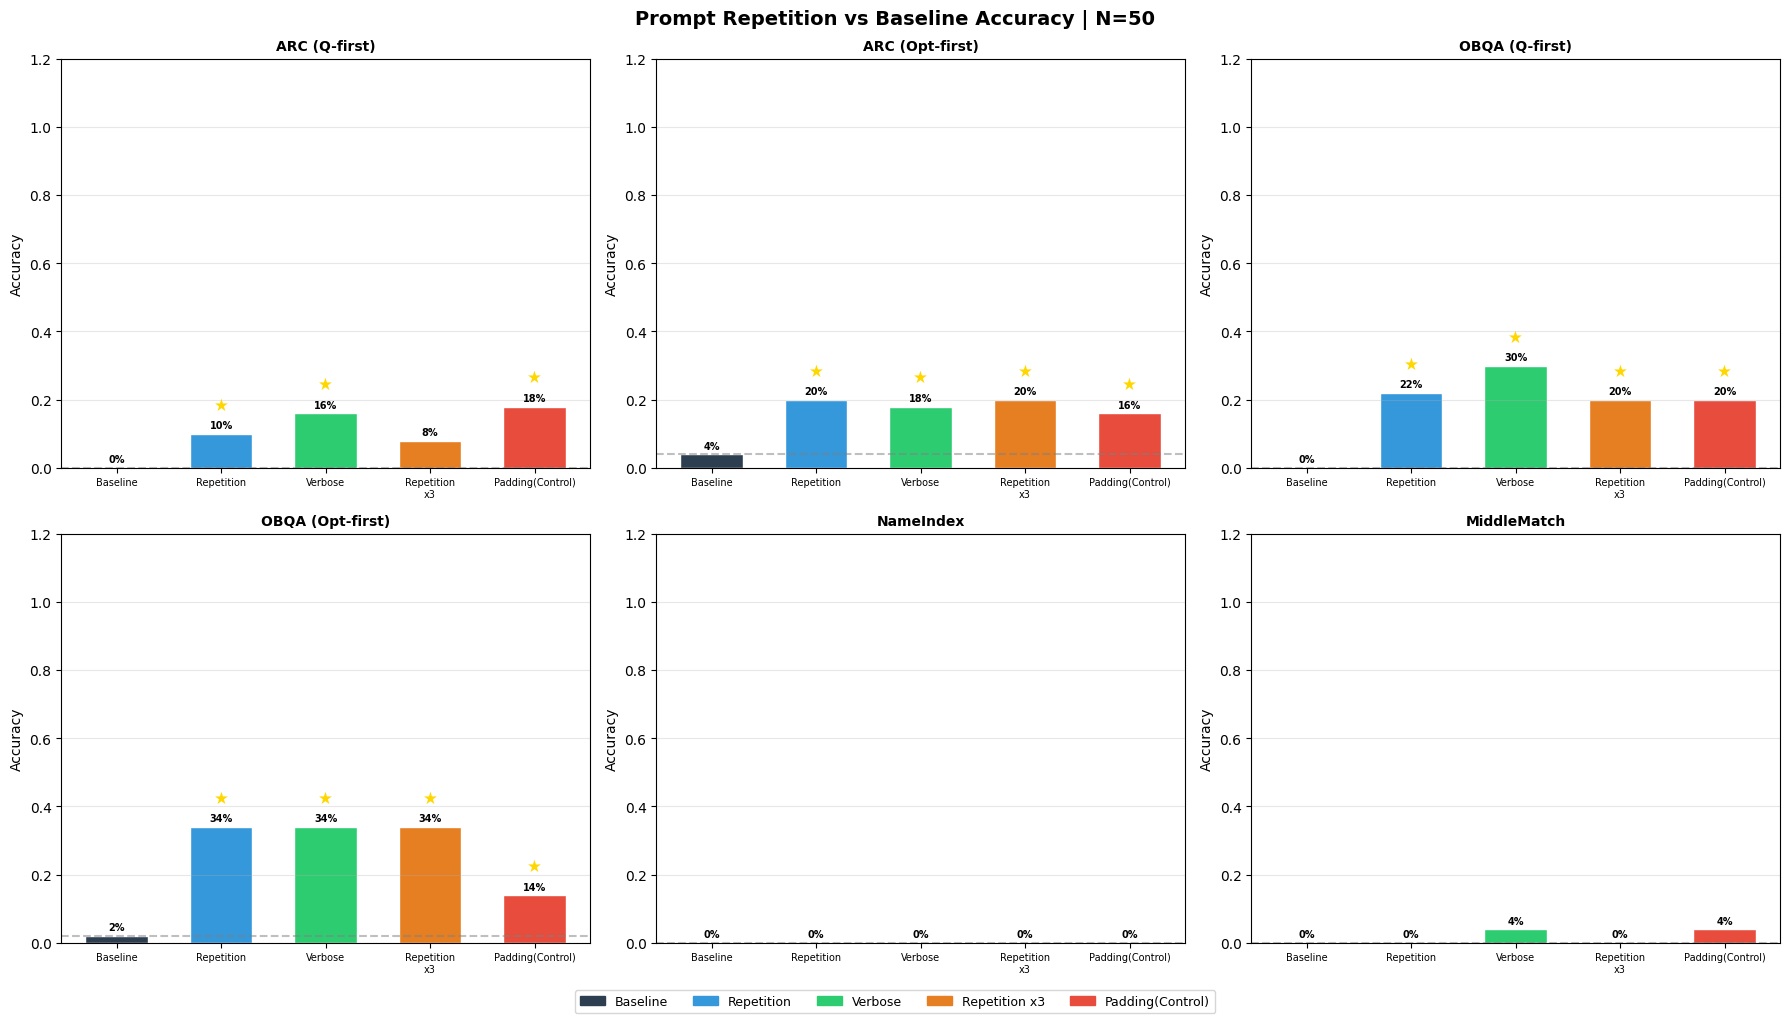

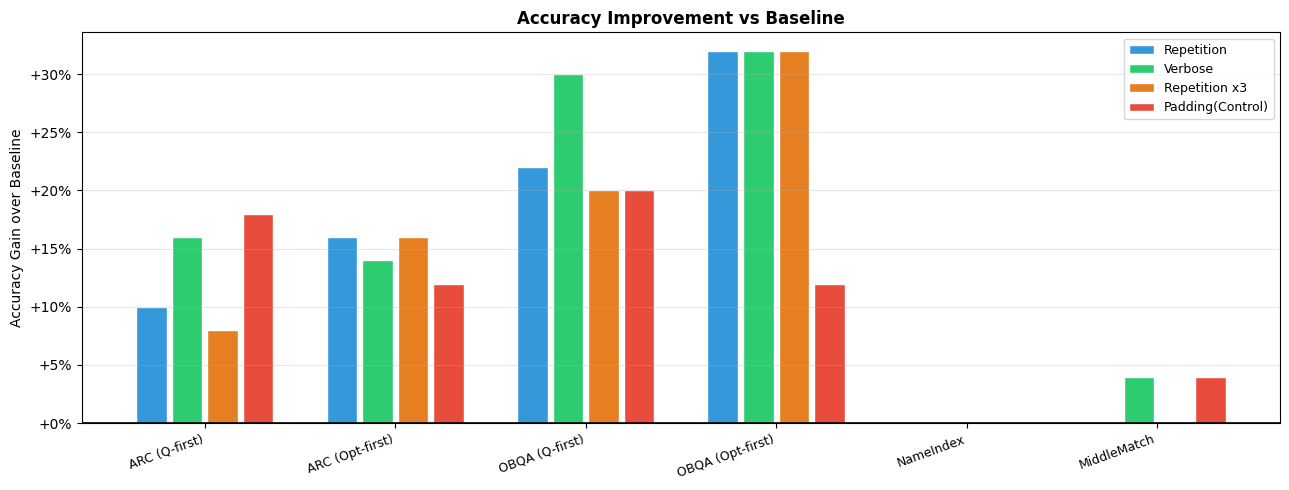

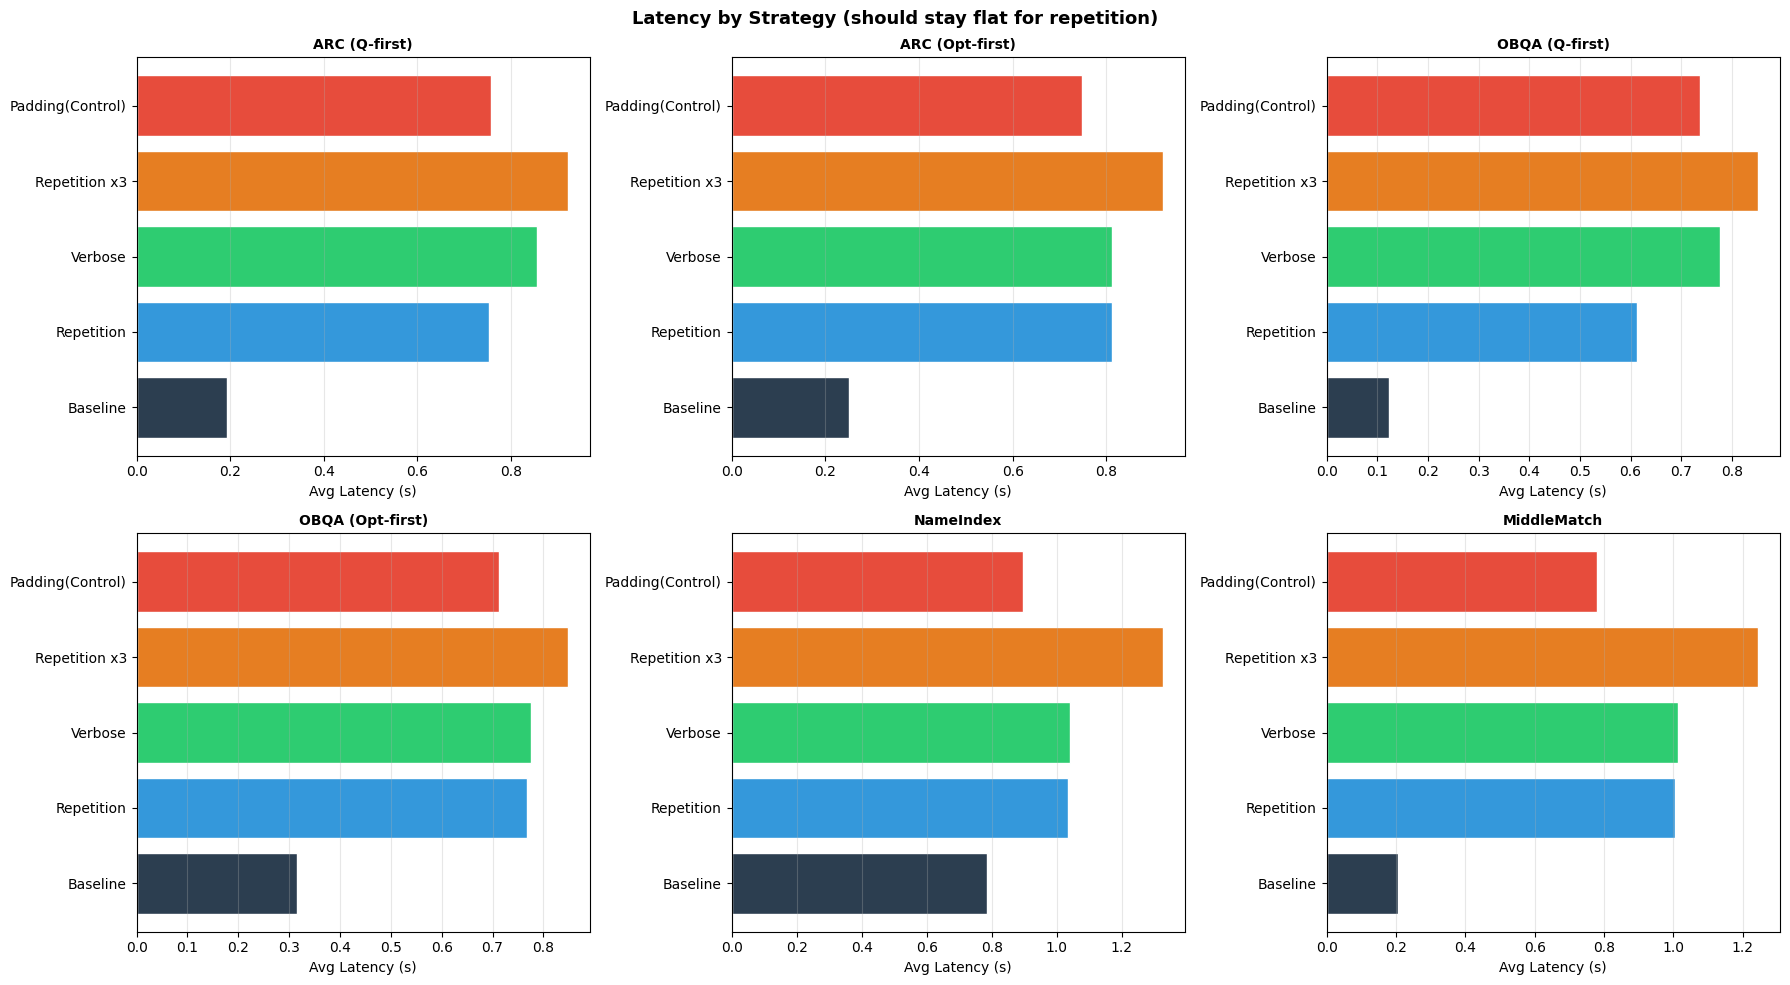

✅ All plots saved!


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

bench_names = list(BENCHMARKS.keys())
strat_names = list(STRATEGIES.keys())

COLORS = {
    "Baseline":         "#2c3e50",
    "Repetition":       "#3498db",
    "Verbose":          "#2ecc71",
    "Repetition x3":    "#e67e22",
    "Padding(Control)": "#e74c3c",
}

# --- Plot 1: Accuracy bars ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
fig.suptitle(f"Prompt Repetition vs Baseline Accuracy | N={N_SAMPLES}", fontsize=14, fontweight='bold')

x = np.arange(len(strat_names))

for ax_idx, bench in enumerate(bench_names):
    ax    = axes[ax_idx]
    accs  = [results[bench][s]["accuracy"] for s in strat_names]
    colors= [COLORS[s] for s in strat_names]
    bars  = ax.bar(x, accs, color=colors, edgecolor='white', width=0.6)

    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{acc:.0%}", ha='center', va='bottom', fontsize=7, fontweight='bold')

    base_correct = results[bench]["Baseline"]["correct"]
    for i, strat in enumerate(strat_names):
        if strat == "Baseline": continue
        _, label = mcnemar_test(base_correct, results[bench][strat]["correct"])
        if "WIN" in label:
            ax.text(i, accs[i]+0.07, "★", ha='center', fontsize=12, color='gold', fontweight='bold')

    ax.set_title(bench, fontsize=10, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([s.replace(" ","\n") for s in strat_names], fontsize=7)
    ax.set_ylim(0, 1.2)
    ax.set_ylabel("Accuracy")
    ax.axhline(results[bench]["Baseline"]["accuracy"], color='gray', linestyle='--', alpha=0.5)
    ax.grid(axis='y', alpha=0.3)

handles = [mpatches.Patch(color=COLORS[s], label=s) for s in strat_names]
fig.legend(handles=handles, loc='lower center', ncol=5, fontsize=9, bbox_to_anchor=(0.5,-0.03))
plt.tight_layout()
plt.savefig("accuracy_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

# --- Plot 2: Accuracy gain over baseline ---
fig, ax = plt.subplots(figsize=(13, 5))
offsets = np.linspace(-0.28, 0.28, 4)
compare = ["Repetition","Verbose","Repetition x3","Padding(Control)"]
x = np.arange(len(bench_names))

for i, strat in enumerate(compare):
    gains = [results[b][strat]["accuracy"] - results[b]["Baseline"]["accuracy"] for b in bench_names]
    ax.bar(x + offsets[i], gains, width=0.16, label=strat, color=COLORS[strat], edgecolor='white')

ax.axhline(0, color='black', linewidth=1.2)
ax.set_xticks(x)
ax.set_xticklabels(bench_names, rotation=20, ha='right', fontsize=9)
ax.set_ylabel("Accuracy Gain over Baseline")
ax.set_title("Accuracy Improvement vs Baseline", fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f"{y:+.0%}"))
plt.tight_layout()
plt.savefig("accuracy_gain.png", dpi=150, bbox_inches='tight')
plt.show()

# --- Plot 3: Latency comparison ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
fig.suptitle("Latency by Strategy (should stay flat for repetition)", fontsize=13, fontweight='bold')

for ax_idx, bench in enumerate(bench_names):
    ax    = axes[ax_idx]
    lats  = [results[bench][s]["avg_latency"] for s in strat_names]
    colors= [COLORS[s] for s in strat_names]
    ax.barh(strat_names, lats, color=colors, edgecolor='white')
    ax.set_title(bench, fontsize=10, fontweight='bold')
    ax.set_xlabel("Avg Latency (s)")
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig("latency_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ All plots saved!")

# Final Summary + Interactive Test

In [ ]:
# --- Summary ---
print("="*60)
print("FINAL SUMMARY")
print("="*60)
for bench in BENCHMARKS:
    base = results[bench]["Baseline"]["accuracy"]
    rep  = results[bench]["Repetition"]["accuracy"]
    print(f"{bench:<22} Baseline: {base:.1%}  Repetition: {rep:.1%}  Gain: {rep-base:+.1%}")

print("\nKey findings to verify:")
print("✅ Repetition accuracy > Baseline accuracy")
print("✅ Padding does NOT improve (proves it's not just longer input)")
print("✅ Latency stays roughly the same")

# --- Interactive: test any query ---
print("\n" + "="*60)
print("INTERACTIVE TEST")
print("="*60)

MY_QUERY = """Which of the following is a renewable energy source?
A. Coal
B. Natural gas
C. Solar power
D. Nuclear fission
Reply with one letter ('A','B','C','D') in the format: The answer is <ANSWER>."""

CORRECT = "C"

print(f"Query:\n{MY_QUERY}\nCorrect: {CORRECT}\n")
for strat_name, strat_fn in STRATEGIES.items():
    prompted = strat_fn(MY_QUERY)
    pred, ntok, lat = run_inference(prompted)
    extracted = extract_letter(pred)
    icon = "✅" if extracted == CORRECT else "❌"
    print(f"{icon} [{strat_name:<18}] → '{pred[:50]}' | Letter: {extracted} | Tokens: {ntok} | {lat:.2f}s")

FINAL SUMMARY
ARC (Q-first)          Baseline: 0.0%  Repetition: 10.0%  Gain: +10.0%
ARC (Opt-first)        Baseline: 4.0%  Repetition: 20.0%  Gain: +16.0%
OBQA (Q-first)         Baseline: 0.0%  Repetition: 22.0%  Gain: +22.0%
OBQA (Opt-first)       Baseline: 2.0%  Repetition: 34.0%  Gain: +32.0%
NameIndex              Baseline: 0.0%  Repetition: 0.0%  Gain: +0.0%
MiddleMatch            Baseline: 0.0%  Repetition: 0.0%  Gain: +0.0%

Key findings to verify:
✅ Repetition accuracy > Baseline accuracy
✅ Padding does NOT improve (proves it's not just longer input)
✅ Latency stays roughly the same

INTERACTIVE TEST
Query:
Which of the following is a renewable energy source?
A. Coal
B. Natural gas
C. Solar power
D. Nuclear fission
Reply with one letter ('A','B','C','D') in the format: The answer is <ANSWER>.
Correct: C

❌ [Baseline          ] → '' | Letter: ? | Tokens: 1 | 0.17s
❌ [Repetition        ] → 'Based on the passage above, Can you provide a summ' | Letter: A | Tokens: 20 | 1.71s
❌ [V